## OCR (Optical Character Recognition)

This OCR app will be used to extract text from an image of handwritten notes.

### PipeLine of  the project

Take the Image of the (hand written Notes) ---> Process the image (CV2-computer vision)-->LLM(Role assigned as OCR)

In [1]:
#pip install opencv-python

In [2]:
import cv2
import matplotlib.pyplot as plt
import google.generativeai as genai
from PIL import Image
import os 

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27732\3040491442.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
image = cv2.imread('mom1.jpg')   # Right now its a BGR image so we need to covert it to RGB image 
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB) #BGR --> RGB
image_gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
_,image_bw = cv2.threshold(image_gray,100,255,cv2.THRESH_BINARY)

In [4]:
# Its a  color image (3D)

image_gray.shape

(971, 700)

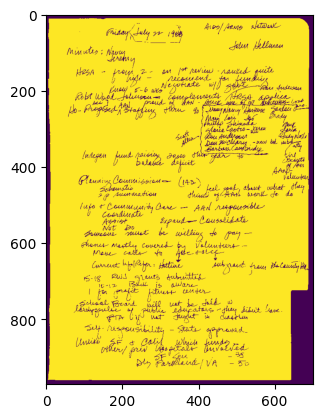

In [5]:
plt.imshow(image_bw)
plt.show()

In [ ]:
cv2.imshow('Grey Image',image_gray)
cv2.imshow('Color',image) 
cv2.imshow('BW',image_bw)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# So the image that cv2 has given is numpy array format , so we need to convert it into image format.

final_image=Image.fromarray(image_bw)

In [ ]:
# Configure an LLM 

gemini_api_key = os.getenv('Google_API_Key2')
genai.configure(api_key=gemini_api_key)
model = genai.GenerativeModel('gemini-2.5-flash-lite',
                              generation_config={'temperature':0.5})


In [ ]:
prompt = '''
<Role> You are and OCR(optical character recognition) application.
<Goal> Identify the characters in handwritten notes.
<Context> User has provided the image  of handwritten notes.
<Instruction> 
* Do not generate any new content.
* You can complete a word which is not recognized.
* Output should be well formated
'''

In [ ]:
response = model.generate_content([prompt,final_image])
print(response.text)

(4) Paragraph: space on the Basis of Paragraph
(5) Semantic: space Based of Semantic
relationship using cosine
similarity to calculat the
semantic ordering.
(6) Standard: English Standard from
lifectul
(7) Sliding window: Needs overlap. Similar
to fixed Size.
(8) Token Based: Based on token size.
I check ~50 token.
(might look carlin wity + Senetic order
-strong)
(9) overlap: If is Input. to maintain
certainty between the checks.


### Extracting text from word doc

In [ ]:
#pip install python-docx


In [ ]:
from docx import Document

In [ ]:
file = Document('sample.docx')

In [ ]:
doc_text = ''
for p in file.paragraphs:
    doc_text=doc_text+p.text+'\n'


print(doc_text)

Key Characteristics
Autonomy & Agency: Acts independently with purpose, rather than just following predefined rules or prompts.
Goal-Oriented: Focuses on achieving higher-level objectives by planning and executing multi-step tasks.
Planning & Reasoning: Breaks down goals into subtasks, strategizes, and uses logic to decide on the best actions.
Tool Use: Connects with external systems (APIs, databases, software) to perform actions, not just generate text.
Learning & Adaptation: Monitors outcomes, learns from interactions, and refines its behavior for better future performance.
Contextual Awareness: Understands the environment and situation to make informed, context-aware decisions. 
v



| File Type   | Extension        | MIME Type                                                                 |
| ----------- | ---------------- | ------------------------------------------------------------------------- |
| Plain text  | `.txt`           | `text/plain`                                                              |
| HTML        | `.html`          | `text/html`                                                               |
| CSV         | `.csv`           | `text/csv`                                                                |
| JSON        | `.json`          | `application/json`                                                        |
| PDF         | `.pdf`           | `application/pdf`                                                         |
| ZIP         | `.zip`           | `application/zip`                                                         |
| JPEG image  | `.jpg` / `.jpeg` | `image/jpeg`                                                              |
| PNG image   | `.png`           | `image/png`                                                               |
| GIF         | `.gif`           | `image/gif`                                                               |
| MP3 audio   | `.mp3`           | `audio/mpeg`                                                              |
| MP4 video   | `.mp4`           | `video/mp4`                                                               |
| Excel       | `.xls`           | `application/vnd.ms-excel`                                                |
| Excel (new) | `.xlsx`          | `application/vnd.openxmlformats-officedocument.spreadsheetml.sheet`       |
| Word        | `.doc`           | `application/msword`                                                      |
| Word (new)  | `.docx`          | `application/vnd.openxmlformats-officedocument.wordprocessingml.document` |